In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

In [ ]:
# 1. PARÁMETROS DEL PROBLEMA

MAX_MESAS = 10
MAX_T = 20
P_RECHAZO = 10
P_CANCEL = 400
P_NOSHOW = 600
alpha = 1
q_cancel = 0.05
p_noshow = 0.025
p_asiste = (1 - q_cancel - p_noshow)

# Ingresos por tipo de menú
INGRESO_ALTO_PREMIUM   = 1300
INGRESO_BAJO_PREMIUM   = 800
INGRESO_ALTO_ESTANDAR  = 400
INGRESO_BAJO_ESTANDAR  = 100

# Defino los 4 tipos y sus probabilidades
TIPOS_MENU = ["A_premium", "B_premium","A_estandar", "B_estandar"]
prob_menu  = {
    "A_premium": 0.2,
    "B_premium": 0.3,
    "A_estandar": 0.35,
    "B_estandar": 0.15
}

# Mapeo genérico
ingreso_map = {
    "A_premium": INGRESO_ALTO_PREMIUM,
    "B_premium": INGRESO_BAJO_PREMIUM,
    "A_estandar": INGRESO_ALTO_ESTANDAR,
    "B_estandar": INGRESO_BAJO_ESTANDAR
}
acciones = [0, 1]  # 0: rechazar, 1: aceptar

# 2. CONSTRUCCIÓN DE ESTADOS Y TRANSICIONES

# Lista de todos los estados válidos
estados = []
for m in range(MAX_MESAS+1):
    for t in range(MAX_T+1):
        for rp in range(MAX_MESAS-m+1):
            re = MAX_MESAS - m - rp
            if re < 0:
                continue
            estados.append((m, t, rp, re))

# Tabla de transiciones (acción, evento, probabilidad, recompensa, próximo estado)
filas = []
for estado in estados:
    m, t, rp, re = estado
    if t == 0:
        continue  # Estado terminal

    for tipo_menu in TIPOS_MENU:
        p_tipo = prob_menu[tipo_menu]
        ingreso = ingreso_map[tipo_menu]

        puede_aceptar = m > 0
        for accion in (acciones if puede_aceptar else [0]):
            if accion == 0:
                # Rechazo
                filas.append({
                    "Estado": f"{m},{t},{rp},{re}",
                    "accion": accion,
                    "tipo_menu": tipo_menu,
                    "recompensa": -P_RECHAZO,
                    "probabilidad": p_tipo,
                    "prox_estado": f"{m},{t-1},{rp},{re}",
                    "evento": "rechazo"
                })
            else:
                # Aceptado: tres posibles eventos (asiste, cancela, noshow)
                m_sig, t_sig = m-1, t-1
                # si contiene la palabra "premium" voy a rp, si no a re
                if "premium" in tipo_menu:
                    rp_sig, re_sig = rp+1, re
                else:
                    rp_sig, re_sig = rp, re+1
                # Asiste
                filas.append({
                    "Estado": f"{m},{t},{rp},{re}",
                    "accion": accion,
                    "tipo_menu": tipo_menu,
                    "recompensa": ingreso,
                    "probabilidad": p_tipo*p_asiste,
                    "prox_estado": f"{m_sig},{t_sig},{rp_sig},{re_sig}",
                    "evento": "asiste"
                })
                # Cancelación
                filas.append({
                    "Estado": f"{m},{t},{rp},{re}",
                    "accion": accion,
                    "tipo_menu": tipo_menu,
                    "recompensa": -P_CANCEL,
                    "probabilidad": p_tipo*q_cancel,
                    "prox_estado": f"{m},{t_sig},{rp},{re}",
                    "evento": "cancelacion"
                })
                # Noshow
                filas.append({
                    "Estado": f"{m},{t},{rp},{re}",
                    "accion": accion,
                    "tipo_menu": tipo_menu,
                    "recompensa": -P_NOSHOW,
                    "probabilidad": p_tipo*p_noshow,
                    "prox_estado": f"{m_sig},{t_sig},{rp_sig},{re_sig}",
                    "evento": "noshow"
                })

tabla = pd.DataFrame(filas)
estados_str = tabla['Estado'].unique()


# 3. FUNCIONES BASE

# Calcula f(x,a,V)
def f(x, a, V, tabla):
    sub = tabla[(tabla['Estado'] == x) & (tabla['accion'] == a)]
    valor_esperado = 0.0
    for _, row in sub.iterrows():
        p = row['probabilidad']
        r = row['recompensa']
        y = row['prox_estado']
        Vy = V.get(y, 0.0)
        valor_esperado += p * (r + alpha * Vy)
    return valor_esperado

# Acción óptima a*(x,V)
def a_estrella(x, V, tabla):
    valores = [f(x, a, V, tabla) for a in acciones]
    return np.argmax(valores), max(valores)

# Una muestra de transición g(x,a): retorna (r, next_state)
def g(x, a, tabla):
    sub = tabla[(tabla['Estado'] == x) & (tabla['accion'] == a)]
    probabilidades = sub['probabilidad'].to_numpy()
    if probabilidades.sum() == 0:
        return 0, x  # Estado terminal
    elegido = np.random.choice(sub.index, p=probabilidades/probabilidades.sum())
    row = sub.loc[elegido]
    return row['recompensa'], row['prox_estado']


# 4. ITERACIÓN DE VALOR
V = {x: 0.0 for x in estados_str}
policy = {x: 0 for x in estados_str}

EPSILON = 1e-3
while True:
    Vn = V.copy()
    delta = 0
    for x in estados_str:
        valores = [f(x, a, V, tabla) for a in acciones]
        if valores:
            Vn[x] = max(valores)
            policy[x] = np.argmax(valores)
            delta = max(delta, abs(Vn[x] - V[x]))
    V = Vn
    if delta < EPSILON:
        break

# 5. TABLA FINAL DE POLÍTICA Y VALOR ÓPTIMO
df_policy = pd.DataFrame([
    {
        "m": int(x.split(",")[0]),
        "t": int(x.split(",")[1]),
        "rp": int(x.split(",")[2]),
        "re": int(x.split(",")[3]),
        "Accion_optima": "Aceptar" if policy[x]==1 else "Rechazar",
        "Valor_optimo": V[x]
    }
    for x in V.keys()
])

# Ejemplo: Accion y Valor óptimo para cada (m,t) con rp=re=0
pivot_accion = df_policy[(df_policy.rp==0) & (df_policy.re==0)].pivot(index="m", columns="t", values="Accion_optima")
pivot_valor = df_policy[(df_policy.rp==0) & (df_policy.re==0)].pivot(index="m", columns="t", values="Valor_optimo")

print("\n---- ACCIÓN ÓPTIMA (rp=0, re=0) ----")
print(pivot_accion)
print("\n---- VALOR ÓPTIMO (rp=0, re=0) ----")
print(pivot_valor)



---- ACCIÓN ÓPTIMA (rp=0, re=0) ----
t        1        2        3        4        5        6        7        8   \
m                                                                            
10  Aceptar  Aceptar  Aceptar  Aceptar  Aceptar  Aceptar  Aceptar  Aceptar   

t        9        10       11       12       13       14       15       16  \
m                                                                            
10  Aceptar  Aceptar  Aceptar  Aceptar  Aceptar  Aceptar  Aceptar  Aceptar   

t        17       18       19       20  
m                                       
10  Aceptar  Aceptar  Aceptar  Aceptar  

---- VALOR ÓPTIMO (rp=0, re=0) ----
t        1        2         3       4         5        6         7       8   \
m                                                                             
10  570.875  1141.75  1712.625  2283.5  2854.375  3425.25  3996.125  4567.0   

t         9        10          11           12           13           14  \
m                 

In [ ]:
# ITERACION DE POLITICAS
policy_PI = {x: 1 if int(x.split(',')[0]) > 0 else 0 for x in estados_str}
V_PI = {x: 0.0 for x in estados_str}

while True:
    Vn = V_PI.copy()
    while True:
        delta = 0
        for x in estados_str:
            a = policy_PI[x]
            valor = f(x, a, Vn, tabla)
            delta = max(delta, abs(valor - Vn[x]))
            Vn[x] = valor
        if delta < 1e-3:
            break
    V_PI = Vn
    policy_stable = True
    for x in estados_str:
        old_action = policy_PI[x]
        actions_values = [f(x, a, V_PI, tabla) for a in acciones]
        best_action = np.argmax(actions_values)
        policy_PI[x] = best_action
        if old_action != best_action:
            policy_stable = False
    if policy_stable:
        break

In [ ]:
#Q-LEARNING
Q = {(x, a): 0.0 for x in estados_str for a in acciones}
visit_counts = defaultdict(int)

N_EPISODIOS = 20000
#ALPHA = 0.1
GAMMA = 1.0
EPSILON = 0.2

for _ in range(N_EPISODIOS):
    estado = "10,20,0,0"
    while True:
        m, t, rp, re = map(int, estado.split(','))
        if t == 0:
            break
        if np.random.rand() < EPSILON:
            accion = np.random.choice(acciones)
        else:
            qvals = [Q[(estado, a)] for a in acciones]
            accion = acciones[np.argmax(qvals)]
        sub = tabla[(tabla["Estado"] == estado) & (tabla["accion"] == accion)]
        probabilidades = sub["probabilidad"].to_numpy()
        if probabilidades.sum() == 0:
            break
        idx_elegido = np.random.choice(sub.index, p=probabilidades / probabilidades.sum())
        row = sub.loc[idx_elegido]
        next_estado = row["prox_estado"]
        recompensa = row["recompensa"]
        maxQ = max([Q.get((next_estado, a), 0.0) for a in acciones])
        xa = (estado, accion)
        visit_counts[xa] += 1
        ALPHA = 1.0 / visit_counts[xa]
        Q[xa] += ALPHA * (recompensa + GAMMA * maxQ - Q[xa])
        estado = next_estado

policy_Q = {x: np.argmax([Q.get((x,a), 0.0) for a in acciones]) for x in estados_str}
V_Q = {x: max([Q.get((x,a), 0.0) for a in acciones]) for x in estados_str}

In [ ]:
# Generar la misma secuencia de reservas/eventos
np.random.seed(40)
path_exog = []
for _ in range(MAX_T):
    tipo = np.random.choice(
        TIPOS_MENU,
        p=[prob_menu[t] for t in TIPOS_MENU]
    )
    evento = np.random.choice(
        ["asiste","cancelacion","noshow"],
        p=[p_asiste, q_cancel, p_noshow]
    )
    path_exog.append((tipo, evento))

In [ ]:
def simular_noche_misma(path, policy, estado_inicial="10,20,0,0"):
    estado = estado_inicial
    total = 0
    historial = []
    for paso, (tipo, evento) in enumerate(path):
        m, t, rp, re = map(int, estado.split(','))
        if t == 0:
            break
        a = policy.get(estado, 0)

        if m == 0:
            a = 0

        if a == 0:
            r = -P_RECHAZO
            next_s = f"{m},{t-1},{rp},{re}"
            evt = "rechazo"
        else:
            ingreso = ingreso_map[tipo]
            # Asistencia
            if evento == "asiste":
                r = ingreso
                m2, t2 = m-1, t-1
                rp2, re2 = (rp+1, re) if "premium" in tipo else (rp, re+1)
                evt = "asiste"

            # Cancelación
            elif evento == "cancelacion":
                r = -P_CANCEL
                m2, t2 = m-1, t-1
                rp2, re2 = (rp+1, re) if "premium" in tipo else (rp, re+1)
                evt = "cancelacion"

            # No-show
            else:  # evento == "noshow"
                r = -P_NOSHOW
                m2, t2 = m-1, t-1
                rp2, re2 = (rp+1, re) if "premium" in tipo else (rp, re+1)
                evt = "noshow"

            next_s = f"{m2},{t2},{rp2},{re2}"

        total += r
        historial.append({
            "Paso": paso,
            "Estado": estado,
            "Accion": a,
            "Tipo_menu": tipo,
            "Evento": evt,
            "Recompensa": r,
            "Prox_estado": next_s,
            "Acumulado": total
        })
        estado = next_s

    return pd.DataFrame(historial), total


In [ ]:
# Ejecutar las tres políticas sobre la misma noche
df_vi, tot_vi = simular_noche_misma(path_exog, policy)
df_pi, tot_pi = simular_noche_misma(path_exog, policy_PI)
df_q , tot_q  = simular_noche_misma(path_exog, policy_Q)

print("---- Value Iteration ----")
print(df_vi);  print("Total VI:", tot_vi, "\n")
print("---- Policy Iteration ----")
print(df_pi);  print("Total PI:", tot_pi, "\n")
print("---- Q-Learning ----")
print(df_q );  print("Total QL:", tot_q)

---- Value Iteration ----
    Paso     Estado  Accion   Tipo_menu   Evento  Recompensa Prox_estado  \
0      0  10,20,0,0       1   B_premium   asiste         800    9,19,1,0   
1      1   9,19,1,0       1  A_estandar   asiste         400    8,18,1,1   
2      2   8,18,1,1       1   B_premium   asiste         800    7,17,2,1   
3      3   7,17,2,1       1  A_estandar   asiste         400    6,16,2,2   
4      4   6,16,2,2       1  A_estandar   asiste         400    5,15,2,3   
5      5   5,15,2,3       1  B_estandar   asiste         100    4,14,2,4   
6      6   4,14,2,4       1  A_estandar   asiste         400    3,13,2,5   
7      7   3,13,2,5       1   A_premium   asiste        1300    2,12,3,5   
8      8   2,12,3,5       1   B_premium   asiste         800    1,11,4,5   
9      9   1,11,4,5       1  A_estandar   asiste         400    0,10,4,6   
10    10   0,10,4,6       0   A_premium  rechazo         -10     0,9,4,6   
11    11    0,9,4,6       0  A_estandar  rechazo         -10  

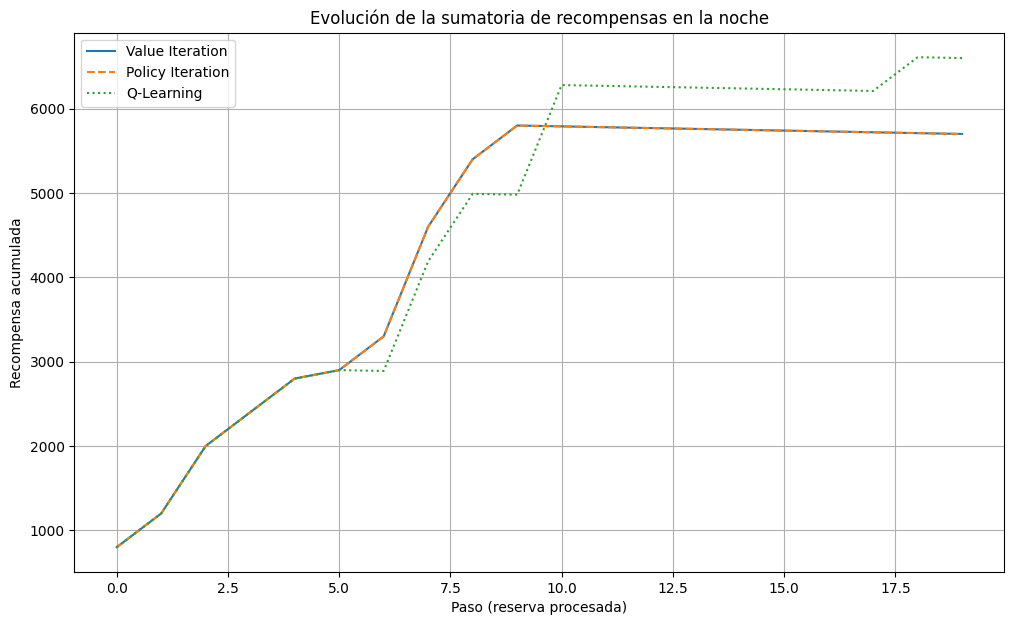

In [ ]:
plt.figure(figsize=(12,7))
plt.plot(df_vi['Acumulado'].values, label='Value Iteration')
plt.plot(df_pi['Acumulado'].values, label='Policy Iteration', linestyle='--')
plt.plot(df_q['Acumulado'].values, label='Q-Learning', linestyle=':')
plt.xlabel('Paso (reserva procesada)')
plt.ylabel('Recompensa acumulada')
plt.title('Evolución de la sumatoria de recompensas en la noche')
plt.legend()
plt.grid(True)
plt.show()